# Checkbox Recognition — SSIP 2025

Portable version of the checkbox-recognition pipeline.

This notebook uses **repository-relative paths**, so it can be run after cloning the repository without changing Google Drive paths.

The original SSIP/Google Colab notebook — including its saved competition-time outputs — is preserved separately in:

`notebooks/Checkbox_Recognition_SSIP2025_original_colab.ipynb`

## Example

| Input | Detected checkboxes |
|---|---|
| <img src="input/scan1.jpg" width="380"> | <img src="output/processed_scan1.jpg" width="380"> |

The system uses classical image processing rather than a trained machine-learning model.

## 1. Imports and project paths

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Repository-relative paths
PROJECT_ROOT = Path.cwd()
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output"
DATASET_DIR = PROJECT_ROOT / "dataset_coordinates"
RESULTS_CSV = PROJECT_ROOT / "checkbox_detection_results.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_dirs = {
    "input": INPUT_DIR,
    "dataset_coordinates": DATASET_DIR,
}

for name, path in required_dirs.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Required folder '{name}' was not found at: {path}\n"
            "Run this notebook from the repository root."
        )

print("Project folders ready: input/, output/, dataset_coordinates/")

Project folders ready: input/, output/, dataset_coordinates/


## 2. Checkbox detection and classification

Pipeline:

1. grayscale conversion and Gaussian blur;
2. adaptive thresholding and morphological processing;
3. contour detection and geometric filtering;
4. ROI analysis using Otsu thresholding;
5. checked/unchecked decision from core-vs-ring pixel statistics;
6. annotated-image and CSV export.

In [3]:
image_files = sorted(
    p for p in INPUT_DIR.iterdir()
    if p.suffix.lower() in {".png", ".jpg", ".jpeg"}
)

if not image_files:
    raise FileNotFoundError(f"No input images found in: {INPUT_DIR}")

min_area_threshold = 1000
all_results = []

for img_path in image_files:
    img_name = img_path.name

    image = cv2.imread(str(img_path))
    if image is None:
        print(f"[WARNING] Could not read: {img_name}")
        continue

    image = cv2.resize(
        image,
        None,
        fx=1.5,
        fy=1.5,
        interpolation=cv2.INTER_LINEAR,
    )

    # Preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        8,
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    morph = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1,
    )
    morph = cv2.dilate(morph, kernel, iterations=1)

    # Candidate checkbox detection
    contours, _ = cv2.findContours(
        morph,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    valid_boxes = []

    for cnt in contours:
        epsilon = 0.03 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        if 4 <= len(approx) <= 6:
            area = cv2.contourArea(approx)
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h if h else 0

            if (
                min_area_threshold < area < 5625
                and 0.5 < aspect_ratio < 1.8
            ):
                too_close = any(
                    abs(x - x2) < 10 and abs(y - y2) < 10
                    for _, x2, y2, _, _ in valid_boxes
                )

                if not too_close:
                    valid_boxes.append((approx, x, y, w, h))

    valid_boxes_sorted = sorted(
        valid_boxes,
        key=lambda box: (box[2], box[1])
    )

    output_img = image.copy()

    # Checkbox status analysis
    for idx, (box, x, y, w, h) in enumerate(valid_boxes_sorted, start=1):
        pad = int(min(w, h) * 0.3)

        x_roi = max(x - pad, 0)
        y_roi = max(y - pad, 0)
        x_end = min(x + w + pad, morph.shape[1])
        y_end = min(y + h + pad, morph.shape[0])

        roi = morph[y_roi:y_end, x_roi:x_end]

        if roi.size == 0:
            continue

        _, roi_thresh = cv2.threshold(
            roi,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU,
        )

        h_roi, w_roi = roi_thresh.shape

        core_w = max(int(w_roi * 0.4), 1)
        core_h = max(int(h_roi * 0.4), 1)
        cx, cy = w_roi // 2, h_roi // 2

        x1 = max(cx - core_w // 2, 0)
        x2 = min(cx + core_w // 2, w_roi)
        y1 = max(cy - core_h // 2, 0)
        y2 = min(cy + core_h // 2, h_roi)

        core = roi_thresh[y1:y2, x1:x2]

        if core.size == 0:
            continue

        core_black = np.sum(core == 0)
        core_black_ratio = core_black / core.size

        ring_pixels = roi_thresh.size - core.size
        ring_black = np.sum(roi_thresh == 0) - core_black
        ring_black_ratio = (
            ring_black / ring_pixels if ring_pixels > 0 else 0
        )

        contrast = core_black_ratio - ring_black_ratio

        # Original SSIP decision logic
        if core_black_ratio > 0.4 and contrast > 0.15:
            status = "No"           # Unchecked
            color = (0, 0, 255)     # Red in BGR
        else:
            status = "Yes"          # Checked
            color = (0, 255, 0)     # Green in BGR

        cv2.drawContours(output_img, [box], -1, color, 2)
        cv2.putText(
            output_img,
            str(idx),
            (x - 30, y + 12),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

        all_results.append(
            {
                "Image": img_name,
                "X": x,
                "Y": y,
                "Status": status,
            }
        )

    output_path = OUTPUT_DIR / f"processed_{img_name}"
    cv2.imwrite(str(output_path), output_img)

df_results = pd.DataFrame(all_results)
df_results.to_csv(RESULTS_CSV, index=False)

print(f"Processed images: {len(image_files)}")
print(f"Detected checkbox candidates: {len(df_results)}")
print("Results CSV: checkbox_detection_results.csv")
print("Annotated images: output/")

Processed images: 30
Detected checkbox candidates: 788
Results CSV: checkbox_detection_results.csv
Annotated images: output/


## 3. Detection evaluation

In [4]:
ground_truth_path = DATASET_DIR / "coordonate_dataset_fara_litere.csv"

df_true = pd.read_csv(ground_truth_path)
df_pred = pd.read_csv(RESULTS_CSV)

true_coords = [tuple(row) for row in df_true[["X", "Y"]].values]
pred_coords = [tuple(row) for row in df_pred[["X", "Y"]].values]

tolerance = 10
true_positives = 0
matched_true = set()

for px, py in pred_coords:
    for idx, (tx, ty) in enumerate(true_coords):
        if idx in matched_true:
            continue

        if abs(px - tx) <= tolerance and abs(py - ty) <= tolerance:
            true_positives += 1
            matched_true.add(idx)
            break

false_positives = len(pred_coords) - true_positives
false_negatives = len(true_coords) - true_positives

detection_score = (
    true_positives
    / (true_positives + false_positives + false_negatives)
)

print("=== Detection Evaluation ===")
print(f"Detection score: {detection_score:.2%}")
print(f"True Positives: {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

=== Detection Evaluation ===
Detection score: 97.22%
True Positives: 768
False Positives: 20
False Negatives: 2


> **Metric note:** this evaluation measures whether detected checkbox **coordinates**
> match the supplied ground-truth coordinates within a ±10-pixel tolerance.
> It should not be interpreted as a separate checked/unchecked classification-accuracy metric.

## 4. Visual example

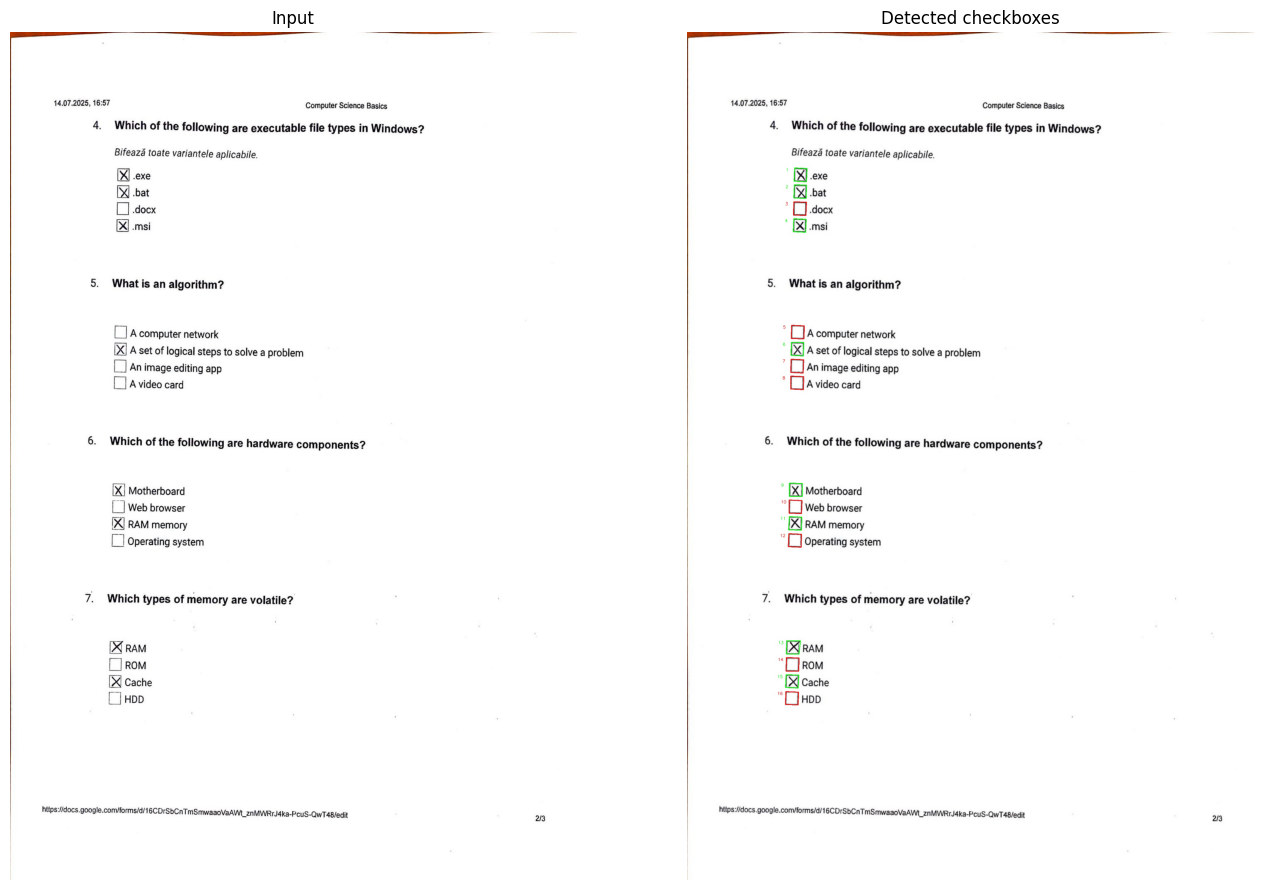

In [5]:
example_name = "scan1.jpg"
input_example = INPUT_DIR / example_name
output_example = OUTPUT_DIR / f"processed_{example_name}"

input_img = cv2.imread(str(input_example))
output_img = cv2.imread(str(output_example))

if input_img is None or output_img is None:
    raise FileNotFoundError(
        "Example images were not found. Run the detection cell first."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Detected checkboxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Notes

- The original SSIP/Colab notebook is kept separately to preserve the original saved outputs.
- This portable notebook removes Google Drive dependencies and uses repository-relative paths.
- The detection and checked/unchecked decision logic remains aligned with the original SSIP implementation; the main changes are portability, robustness, and presentation.